In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# data = pd.read_csv('./figure_2/data/2B.csv')
# data = data.pivot_table(index='sample_id', columns='metabolite', values='flux', fill_value=0.0)
# pca = PCA(n_components=2, random_state=42)
# pca_results = pca.fit_transform(data.values)
# data = pd.DataFrame(pca_results, index=data.index, columns=['PC1', 'PC2']).reset_index()
# data['sample'] = data['sample_id'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')
# pc1_var = pca.explained_variance_ratio_[0] * 100
# pc2_var = pca.explained_variance_ratio_[1] * 100
# data

In [16]:
pcoa_results.proportion_explained.values[1]

0.1169028879473335

In [23]:
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
abundance = pd.read_csv('./goll_et.al_2020_IBS_FMT/processed/abundance_normalized_table.csv')
abundance = abundance.loc[:, ~abundance.columns.str.endswith('-6')]
column_sums = abundance.drop('taxon_id', axis=1).sum(axis=0)
abundance.iloc[:, 1:] = abundance.iloc[:, 1:].div(column_sums, axis=1)
abundance.set_index('taxon_id', inplace=True)
distMatrix = beta_diversity(metric='braycurtis', counts=abundance.T.values, ids=abundance.columns)
pcoa_results = pcoa(distance_matrix=distMatrix, number_of_dimensions=2)
diversity = pcoa_results.samples.reset_index()
diversity['sample'] = diversity['index'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient')
pcoa1_var = pcoa_results.proportion_explained.values[0] * 100
pcoa2_var = pcoa_results.proportion_explained.values[1] * 100

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.05684916252297307 and the largest is 2.5176361497028705.
  warn(


Text(0, 0.5, 'PC2 (11.7%)')

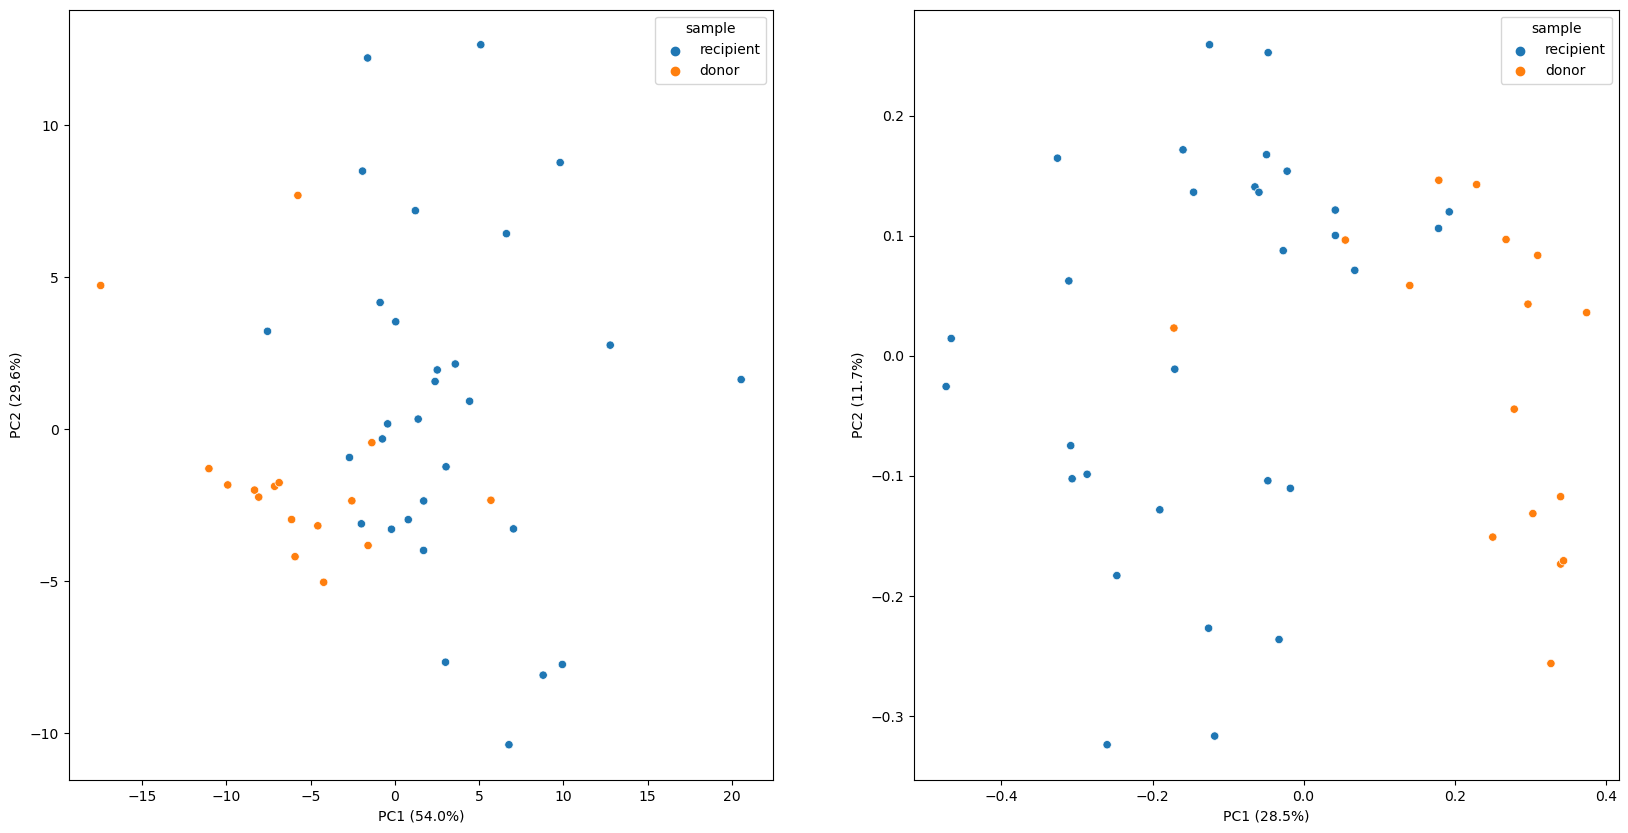

In [ ]:
f, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.scatterplot(
    data=data,
    x='PC1',
    y='PC2',
    hue='sample',
    ax=axes[0]
)
axes[0].set_xlabel(f'PC1 ({pc1_var:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pc2_var:.1f}%)')

sns.scatterplot(
    data=diversity,
    x='PC1',
    y='PC2',
    hue='sample',
    ax=axes[1]
)
axes[1].set_xlabel(f'PC1 ({pcoa1_var:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pcoa2_var:.1f}%)')

In [3]:
kegg_ko_results = pd.read_csv('./kegg_ko.csv', index_col=0)
kegg_ko_results = (
    kegg_ko_results
    .dropna(subset=['orthology'])
    .assign(orthology=kegg_ko_results['orthology'].str.split('; '))
    .explode(column=['orthology'])
)
ko_counts = pd.read_table('/Users/zetianzhang/UrtechoLab/human/processed/agora_metabolism/agora_metabolism-enzyme_hits-MATRIX.txt')
ko_counts = (
    ko_counts
    .query('enzyme.isin(@kegg_ko_results.orthology)')
    .set_index('enzyme')
    .clip(upper=1)
)
ref_taxonomy = pd.read_csv('./goll_et.al_2020_IBS_FMT/processed/reference_taxonomy.csv')
ref_taxonomy = ref_taxonomy[ref_taxonomy['id'].isin(ko_counts.columns)]
ko_counts

,Abiotrophia_defectiva_ATCC_49176,Achromobacter_xylosoxidans_A8,Achromobacter_xylosoxidans_NBRC_15126,Acidaminococcus_fermentans_DSM_20731,Acidaminococcus_intestini_RyC_MR95,Acidaminococcus_sp_D21,Acinetobacter_baumannii_AB0057,Acinetobacter_calcoaceticus_PHEA_2,Acinetobacter_haemolyticus_NIPH_261,Acinetobacter_johnsonii_SH046,...,Weissella_cibaria_KACC_11862,Weissella_confusa_LBAE_C39_2,Weissella_paramesenteroides_ATCC_33313,Yersinia_bercovieri_ATCC_43970,Yersinia_enterocolitica_subsp_enterocolitica_8081,Yersinia_frederiksenii_ATCC_33641,Yersinia_kristensenii_ATCC_33638,Yersinia_pseudotuberculosis_YPIII,Yersinia_rohdei_ATCC_43380,Yokenella_regensburgei_ATCC_43003
enzyme,,,,,,,,,,,,,,,,,,,,,
K00122,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K00123,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K00124,0,1,1,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1
K00125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K00126,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K23756,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K24012,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
K25123,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# find bacteroidetes in agora genomes
bacteroidetes = ref_taxonomy[ref_taxonomy['order'] == 'Bacteroidales']['id'].unique()
rest_genomes = [col for col in ko_counts.columns if col not in bacteroidetes]
n_bacteroidetes = len(bacteroidetes)
n_rest = len(rest_genomes)

fisher_results = []
for ko in ko_counts.index:
    bacteroidetes_counts = ko_counts.loc[ko, bacteroidetes].sum()
    rest_counts = ko_counts.loc[ko, rest_genomes].sum()
    
    if bacteroidetes_counts == 0 and rest_counts == 0:
        continue # skip if no variation

    contingency_table = [
        [bacteroidetes_counts, n_bacteroidetes - bacteroidetes_counts],
        [rest_counts, n_rest - rest_counts]
    ]

    odds_ratio, p_value = fisher_exact(contingency_table)
    fisher_results.append({'orthology': ko, 'p': p_value, 'odds_ratio': odds_ratio})

fisher_results_df = (
    pd.DataFrame(fisher_results)
    .assign(
        q=lambda x: multipletests(x['p'], method='fdr_bh')[1],
        odds_ratio=lambda x: x['odds_ratio'].clip(upper=100, lower=0.001), # remove inf values
        log2_odds_ratio=lambda x: np.log2(x['odds_ratio']),
        neglog10_q=lambda x: -np.log10(x['q']),
        significance=lambda x: np.where(
            x['q'] >= 0.05,
            'n.s.',
            np.where(
                x['odds_ratio'] > 1,
                'enriched',
                'depleted'
            )
        )
    )
    .merge(
        kegg_ko_results.drop_duplicates(subset=['orthology']), 
        on='orthology', how='left')
)
fisher_results_df = (
    fisher_results_df
    .assign(pathway=lambda x: x['pathway'].str.split('; '))
    .explode(column='pathway')
    .query('~pathway.str.contains("rn01100", na=True) & ~pathway.str.contains("rn01120", na=True)')
)
fisher_results_df

,orthology,p,odds_ratio,q,log2_odds_ratio,neglog10_q,significance,reaction,metabolite,definition,name,comment,enzyme,pathway
0,K00122,2.361631e-01,0.001,3.797758e-01,-9.965784,0.420473,n.s.,R00519,formate,Formate + NAD+ <=> H+ + CO2 + NADH,formate:NAD+ oxidoreductase,NaN,1.17.1.9,rn00630: Glyoxylate and dicarboxylate metabolism
0,K00122,2.361631e-01,0.001,3.797758e-01,-9.965784,0.420473,n.s.,R00519,formate,Formate + NAD+ <=> H+ + CO2 + NADH,formate:NAD+ oxidoreductase,NaN,1.17.1.9,rn00680: Methane metabolism
0,K00122,2.361631e-01,0.001,3.797758e-01,-9.965784,0.420473,n.s.,R00519,formate,Formate + NAD+ <=> H+ + CO2 + NADH,formate:NAD+ oxidoreductase,NaN,1.17.1.9,rn01200: Carbon metabolism
1,K00123,2.912379e-10,0.001,1.732866e-09,-9.965784,8.761235,depleted,R00519,formate,Formate + NAD+ <=> H+ + CO2 + NADH,formate:NAD+ oxidoreductase,NaN,1.17.1.9,rn00630: Glyoxylate and dicarboxylate metabolism
1,K00123,2.912379e-10,0.001,1.732866e-09,-9.965784,8.761235,depleted,R00519,formate,Formate + NAD+ <=> H+ + CO2 + NADH,formate:NAD+ oxidoreductase,NaN,1.17.1.9,rn00680: Methane metabolism
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,K25123,6.065871e-01,0.001,8.020429e-01,-9.965784,0.095802,n.s.,R12754,formate,Formate + 2 H+ <=> CO2 + Hydrogen,formate:proton oxidoreductase,formate dehydrogenase (hydrogen),1.17.98.5,rn01200: Carbon metabolism
117,K25124,6.065871e-01,0.001,8.020429e-01,-9.965784,0.095802,n.s.,R12754,formate,Formate + 2 H+ <=> CO2 + Hydrogen,formate:proton oxidoreductase,formate dehydrogenase (hydrogen),1.17.98.5,rn00680: Methane metabolism
117,K25124,6.065871e-01,0.001,8.020429e-01,-9.965784,0.095802,n.s.,R12754,formate,Formate + 2 H+ <=> CO2 + Hydrogen,formate:proton oxidoreductase,formate dehydrogenase (hydrogen),1.17.98.5,rn00720: Other carbon fixation pathways
117,K25124,6.065871e-01,0.001,8.020429e-01,-9.965784,0.095802,n.s.,R12754,formate,Formate + 2 H+ <=> CO2 + Hydrogen,formate:proton oxidoreductase,formate dehydrogenase (hydrogen),1.17.98.5,rn01200: Carbon metabolism


In [9]:
fisher_results_df.groupby(['metabolite'])['significance'].value_counts()

metabolite  significance
acetate     depleted        37
            n.s.            31
            enriched        12
butyrate    enriched         1
formate     n.s.            66
            depleted        37
            enriched        23
propionate  n.s.             3
            depleted         1
            enriched         1
Name: count, dtype: int64

In [10]:
plt.figure(figsize=(20,20), dpi=450)
sns.scatterplot(
    data=fisher_results_df,
    x='log2_odds_ratio',
    y='neglog10_q',
    hue='significance',
    style='metabolite'
)
plt.axhline(y=1.33, color='gray', linestyle='--')
plt.axvline(x=2, color='gray', linestyle='--')
plt.axvline(x=-2, color='gray', linestyle='--')

In [47]:
import re
import pandas as pd
from micom.workflows import load_results
from skbio.diversity import beta_diversity
from itertools import product
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [27]:
res_simulated = load_results('./goll_et.al_2020_IBS_FMT/models_simulated/res_western_simulated.zip')
res_actual = load_results('./goll_et.al_2020_IBS_FMT/models/res_western.zip')

DonorRecipientMapping = pd.read_csv('./goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')[['recipient', 'donor', 'clinical_response']]
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient t6'] = DonorRecipientMapping['recipient'].str.split('_').str[0].str.replace('-0', '-6')
DonorRecipientMapping['recipient t0'] = DonorRecipientMapping['recipient'].str.split('_').str[0]
donors = list(set(DonorRecipientMapping['donor'].unique()).intersection(set(res_actual.growth_rates.sample_id.unique())))
recipients_t6 = list(set(DonorRecipientMapping['recipient t6'].unique()).intersection(set(res_actual.growth_rates.sample_id.unique())))
recipients_t0 = [re.split('-', x)[0] + '-0' for x in recipients_t6]

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


In [ ]:
abundance_actual_t6 = (
    res_actual.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('sample_id.isin(@donors) | sample_id.isin(@recipients_t6)')
    .merge(
        DonorRecipientMapping[['donor', 'recipient t6']],
        left_on='sample_id',
        right_on='recipient t6',
        how='left'
    )
    .assign(
        comparison=lambda x: np.where(
            x['sample_id'].str.startswith('D'),
            x['sample_id'],
            x['donor'] + '_vs_' + x['recipient t6'].str.replace('-6', '-0')
        )
    )
    .pivot_table(
        index='taxon',
        columns='comparison',
        values='abundance',
        fill_value=0.0
    )
)
abundance_actual_donors = abundance_actual_t6.loc[:, ~abundance_actual_t6.columns.str.endswith('-0')]
abundance_actual_recipients_t6 = abundance_actual_t6.loc[:, abundance_actual_t6.columns.str.endswith('-0')]

abundance_calculated_t6 = (
    res_simulated.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('~sample_id.isin(@abundance_actual_recipients_t6.columns)')
    .assign(
        donor=lambda x: x['sample_id'].str.split('_vs_').str[0]
    )
    .query('donor.isin(@donors)')
    .pivot_table(index='taxon', columns='sample_id', values='abundance', fill_value=0.0)
)
abundance_all_t6 = pd.concat([abundance_actual_donors, abundance_actual_recipients_t6, abundance_calculated_t6], axis=1).fillna(0)
b_t6 = beta_diversity(metric='braycurtis', counts=abundance_all_t6.T.values)
distMatrix_t6 = pd.DataFrame(b_t6.data, index=abundance_all_t6.T.index, columns=abundance_all_t6.T.index)

bray_curtis_dissimilarity_t6 = {
    'donor': [],
    'recipient': [],
    'score': [],
    'time': []
}

for donor, recipient_t0 in product(donors, recipients_t0):
    recipient = donor + '_vs_' + recipient_t0
    bray_curtis_dissimilarity_t6['donor'].append(donor)
    bray_curtis_dissimilarity_t6['recipient'].append(re.sub('-0', '-6', recipient_t0))
    bray_curtis_dissimilarity_t6['score'].append(distMatrix_t6.loc[donor, recipient])
    bray_curtis_dissimilarity_t6['time'].append('T6')

bray_curtis_dissimilarity_t6 = (
    pd.DataFrame(bray_curtis_dissimilarity_t6)
    .merge(
        DonorRecipientMapping[['recipient t6', 'clinical_response']],
        left_on='recipient',
        right_on='recipient t6',
        how='left'
    )
    .drop(columns=['recipient t6'])
)
bray_curtis_dissimilarity_t6['clinical_response'] = pd.Categorical(bray_curtis_dissimilarity_t6['clinical_response'], ['responder', 'non-responder'], ordered=True)
bray_curtis_dissimilarity_t6

,donor,recipient,score,time,clinical_response
0,D-14,77-6,0.646014,T6,responder
1,D-14,25-6,0.455329,T6,responder
2,D-14,89-6,0.462372,T6,responder
3,D-14,59-6,0.556963,T6,responder
4,D-14,16-6,0.613637,T6,responder
...,...,...,...,...,...
235,D-6Fresk,22-6,0.616906,T6,non-responder
236,D-6Fresk,24-6,0.522347,T6,responder
237,D-6Fresk,75-6,0.473829,T6,non-responder
238,D-6Fresk,31-6,0.487098,T6,responder


In [62]:
abundance_actual_t0 = (
    res_actual.growth_rates[['sample_id', 'taxon', 'abundance']]
    .query('sample_id.isin(@donors) | sample_id.isin(@recipients_t0)')
    .merge(
        DonorRecipientMapping[['donor', 'recipient t0']],
        left_on='sample_id',
        right_on='recipient t0',
        how='left'
    )
    .pivot_table(
        index='taxon',
        columns='sample_id',
        values='abundance',
        fill_value=0.0
    )
)
b_t0 = beta_diversity('braycurtis', counts=abundance_actual_t0.T.values)
distMatrix_t0 = pd.DataFrame(b_t0.data, index=abundance_actual_t0.T.index, columns=abundance_actual_t0.T.index)

bray_curtis_dissimilarity_t0 = {
    'donor': [],
    'recipient': [],
    'score': [],
    'time': []
}

for donor, recipient_t0 in product(donors, recipients_t0):
    bray_curtis_dissimilarity_t0['donor'].append(donor)
    bray_curtis_dissimilarity_t0['recipient'].append(recipient_t0)
    bray_curtis_dissimilarity_t0['score'].append(distMatrix_t0.loc[donor, recipient_t0])
    bray_curtis_dissimilarity_t0['time'] = 'T0'

bray_curtis_dissimilarity_t0 = (
    pd.DataFrame(bray_curtis_dissimilarity_t0)
    .merge(
        DonorRecipientMapping[['recipient t0', 'clinical_response']],
        left_on='recipient',
        right_on='recipient t0',
        how='left'
    )
    .drop(columns=['recipient t0'])
)
bray_curtis_dissimilarity_t0['clinical_response'] = pd.Categorical(bray_curtis_dissimilarity_t0['clinical_response'], ['responder', 'non-responder'], ordered=True)
bray_curtis_dissimilarity_t0

,donor,recipient,score,time,clinical_response
0,D-14,77-0,0.840739,T0,responder
1,D-14,25-0,0.503195,T0,responder
2,D-14,89-0,0.454154,T0,responder
3,D-14,59-0,0.673112,T0,responder
4,D-14,16-0,0.813799,T0,responder
...,...,...,...,...,...
235,D-6Fresk,22-0,0.838984,T0,non-responder
236,D-6Fresk,24-0,0.554922,T0,responder
237,D-6Fresk,75-0,0.521877,T0,non-responder
238,D-6Fresk,31-0,0.507146,T0,responder


In [63]:
bray_curtis_dissimilarity = pd.concat([bray_curtis_dissimilarity_t0, bray_curtis_dissimilarity_t6], axis=0, ignore_index=True)
bray_curtis_dissimilarity

,donor,recipient,score,time,clinical_response
0,D-14,77-0,0.840739,T0,responder
1,D-14,25-0,0.503195,T0,responder
2,D-14,89-0,0.454154,T0,responder
3,D-14,59-0,0.673112,T0,responder
4,D-14,16-0,0.813799,T0,responder
...,...,...,...,...,...
475,D-6Fresk,22-6,0.616906,T6,non-responder
476,D-6Fresk,24-6,0.522347,T6,responder
477,D-6Fresk,75-6,0.473829,T6,non-responder
478,D-6Fresk,31-6,0.487098,T6,responder


<Axes: xlabel='donor', ylabel='score'>

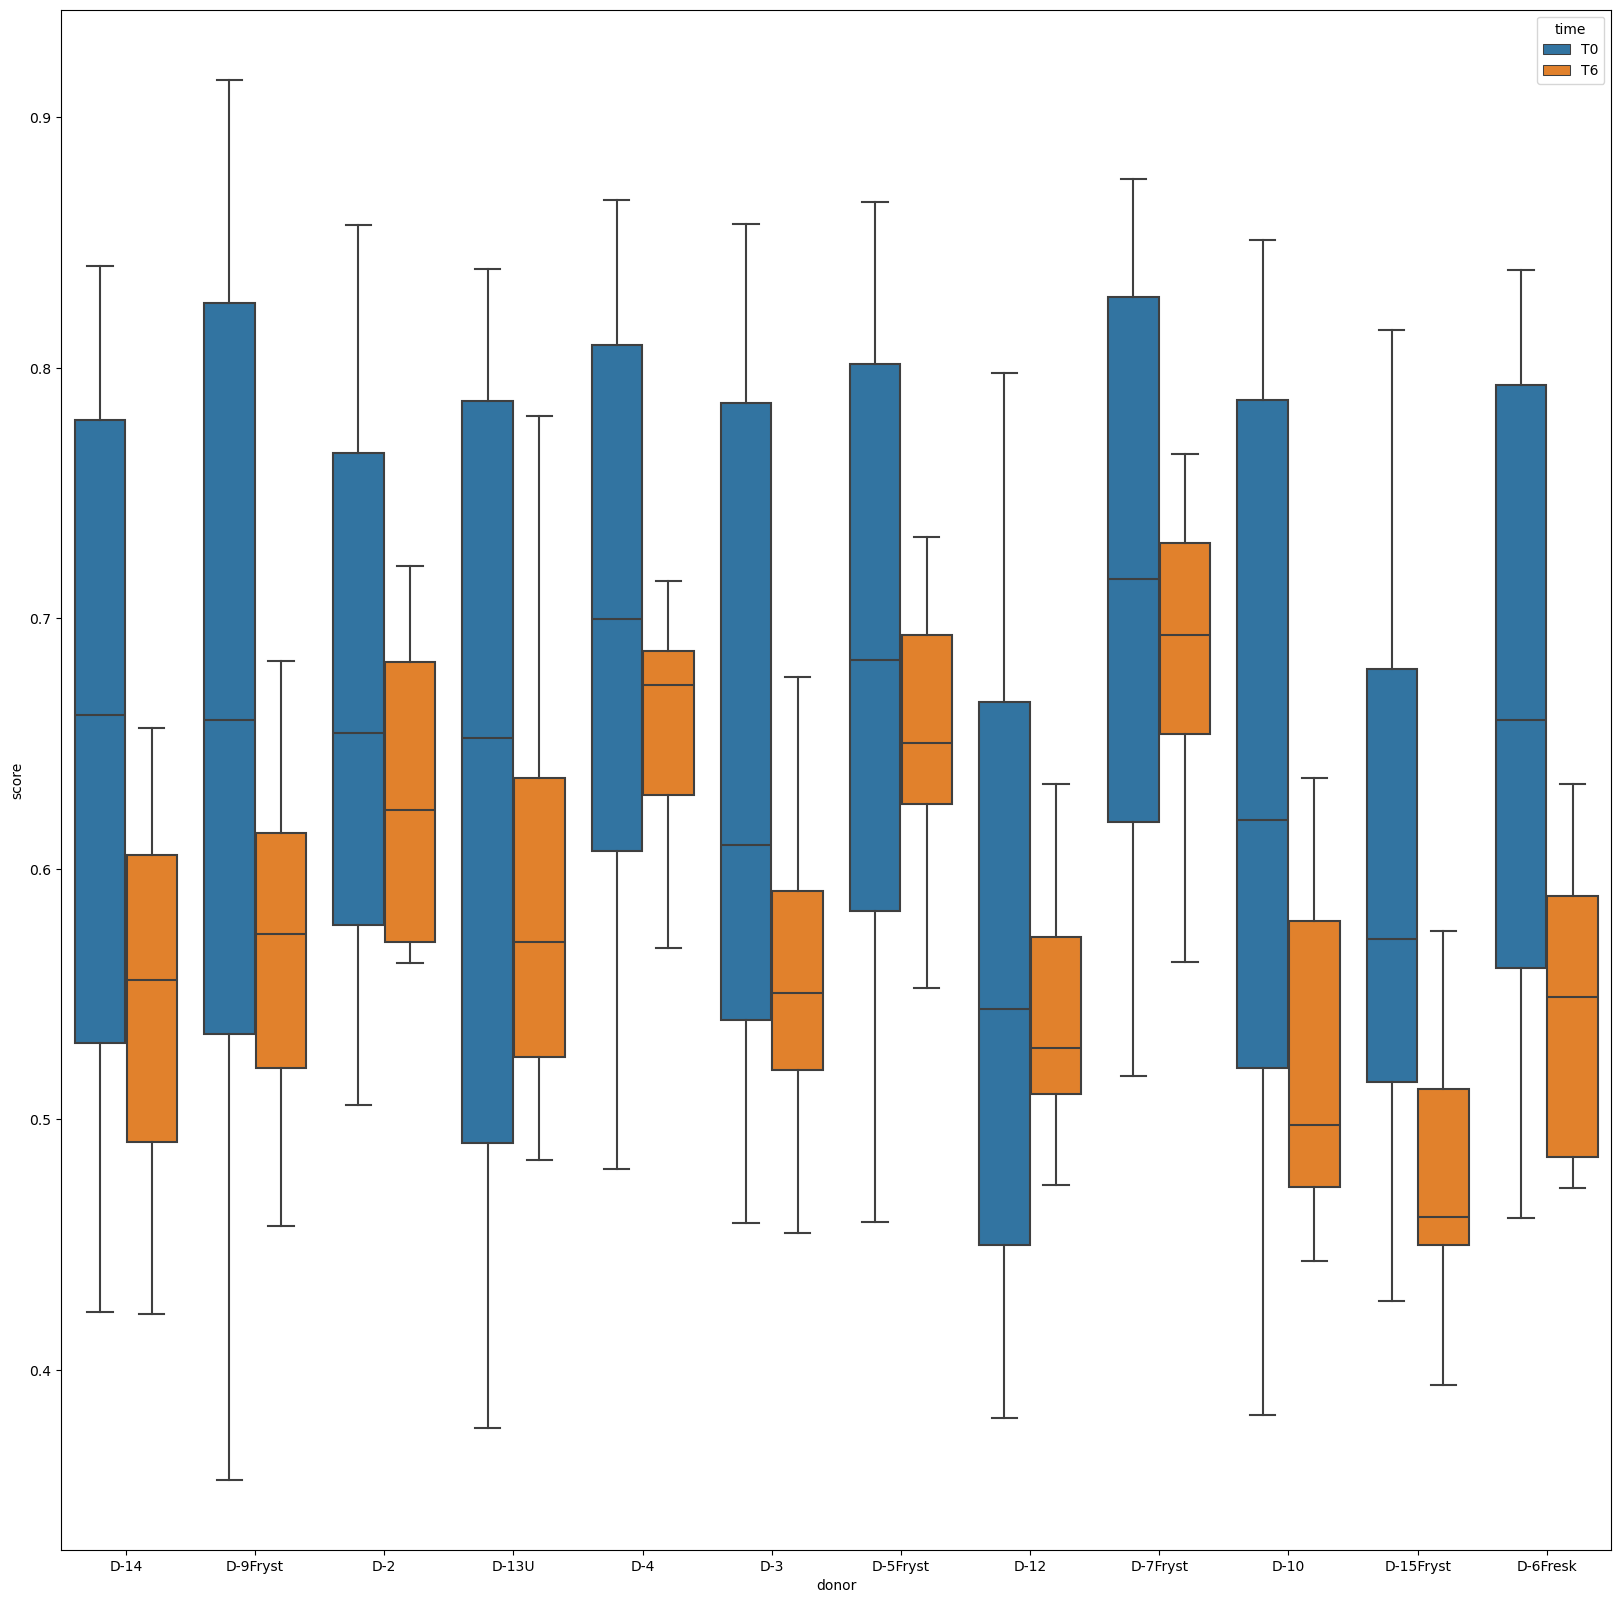

In [ ]:
plt.figure(figsize=(20,20))
sns.boxplot(data=bray_curtis_dissimilarity,
            x='donor',
            y='score',
            hue='time',
            showfliers=False)
# sns.stripplot(data=bray_curtis_dissimilarity_t6,
#               x='donor',
#               y='score',
#               hue='time',
#               dodge=True,
#               jitter=True)

In [2]:
from micom.workflows import load_results
from micom.measures import production_rates

In [3]:
res = load_results('./goll_et.al_2020_IBS_FMT/models/res_western.zip')
ref_taxonomy = pd.read_csv('./goll_et.al_2020_IBS_FMT/processed/full_taxonomy.csv')
DonorRecipientMapping = pd.read_csv('./goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


In [20]:
donors = list(set([x for x in DonorRecipientMapping['donor'].str.split('_').str[0] if x.startswith('D')]))
recipients_t6 = [x.replace('-0', '-6') for x in DonorRecipientMapping['recipient'].str.split('_').str[0] if x.endswith('-0')]

# filter to the same recipients and donors as the models
recipients_t6 = [x for x in recipients_t6 if x in res.growth_rates.sample_id.unique()]
recipients_t0 = [x for x in res.growth_rates.sample_id.unique() if x.endswith('-0')]
donors = [x for x in donors if x in res.growth_rates.sample_id.unique()]
scfas = ['but[e]', 'ppa[e]', 'val[e]', 'ac[e]', 'for[e]']

combined_donor = (
    res.exchanges
    .query('sample_id.isin(@donors)')
    .drop(columns=res.exchanges.columns.difference(['abundance', 'taxon', 'flux', 'metabolite', 'sample_id', 'direction']))
    .query('metabolite.isin(@scfas) & taxon != "medium"')
    .assign(taxon=lambda x: x['taxon'].astype(str),
            flux=lambda x: np.where(
                x['direction'] == 'export',
                x['flux'] * x['abundance'],
                0
            ))
    .groupby(['taxon', 'sample_id'], as_index=False).agg(
        {
            'abundance': 'first',
            'flux': 'sum'
        }
    )
    .merge(
        ref_taxonomy[['phylum', 'order', 'taxon_id']] # try phylum level, if rank too high, lower to order
        .assign(taxon_id=lambda x: x['taxon_id'].astype(str)),
        left_on='taxon',
        right_on='taxon_id',
        how='left')
    .assign(phylum=lambda x: np.where(
        x['phylum'] == 'Bacteroidetes',
        'Bacteroidetes',
        'non-Bacteroidetes'
    ))
    .drop(columns=['taxon_id'])
    .groupby(['phylum', 'sample_id'], as_index=False).agg(
        {
            'flux': 'sum',
            'abundance': 'sum'
        }
    )
    .pivot(
        index='sample_id',
        columns='phylum',
        values=['abundance', 'flux']
    )
    .sort_index(axis=1)
)

combined_donor.columns = [f'{a}_{b}' for a,b in combined_donor.columns]
combined_donor.reset_index(inplace=True)
combined_donor['bact_alr'] = np.log(combined_donor['abundance_Bacteroidetes']) - np.log1p(-combined_donor['abundance_Bacteroidetes'])
combined_donor['scfa_total'] = combined_donor['flux_Bacteroidetes'] + combined_donor['flux_non-Bacteroidetes']
combined_donor['log_scfa_total'] = np.log(combined_donor['scfa_total'])
combined_donor = combined_donor[['bact_alr', 'log_scfa_total']]
combined_donor['group'] = 'donor'
combined_donor

,bact_alr,log_scfa_total,group
0,1.680165,3.756131,donor
1,0.437199,4.079766,donor
2,1.424386,3.840180,donor
3,0.985845,3.669210,donor
4,0.271994,3.868908,donor
5,1.061604,3.682200,donor
6,1.010859,3.717412,donor
7,2.002611,3.508691,donor
8,1.795448,3.629947,donor
9,1.462155,3.773505,donor


In [21]:
combined_recipients_t0 = (
    res.exchanges
    .query('sample_id.isin(@recipients_t0)')
    .drop(columns=res.exchanges.columns.difference(['abundance', 'taxon', 'flux', 'metabolite', 'sample_id', 'direction']))
    .query('metabolite.isin(@scfas) & taxon != "medium"')
    .assign(taxon=lambda x: x['taxon'].astype(str),
            flux=lambda x: np.where(
                x['direction'] == 'export',
                x['flux'] * x['abundance'],
                0
            ))
    .groupby(['taxon', 'sample_id'], as_index=False).agg(
        {
            'abundance': 'first',
            'flux': 'sum'
        }
    )
    .merge(
        ref_taxonomy[['phylum', 'order', 'taxon_id']] # try phylum level, if rank too high, lower to order
        .assign(taxon_id=lambda x: x['taxon_id'].astype(str)),
        left_on='taxon',
        right_on='taxon_id',
        how='left')
    .assign(phylum=lambda x: np.where(
        x['phylum'] == 'Bacteroidetes',
        'Bacteroidetes',
        'non-Bacteroidetes'
    ))
    .drop(columns=['taxon_id'])
    .groupby(['phylum', 'sample_id'], as_index=False).agg(
        {
            'flux': 'sum',
            'abundance': 'sum'
        }
    )
    .pivot(
        index='sample_id',
        columns='phylum',
        values=['abundance', 'flux']
    )
    .sort_index(axis=1)
)
combined_recipients_t0.columns = [f'{a}_{b}' for a, b in combined_recipients_t0.columns]
combined_recipients_t0.reset_index(inplace=True)
combined_recipients_t0['bact_alr'] = np.log(combined_recipients_t0['abundance_Bacteroidetes']) - np.log1p(-combined_recipients_t0['abundance_Bacteroidetes'])
combined_recipients_t0['scfa_total'] = combined_recipients_t0['flux_Bacteroidetes'] + combined_recipients_t0['flux_non-Bacteroidetes']
combined_recipients_t0['log_scfa_total'] = np.log(combined_recipients_t0['scfa_total'])
combined_recipients_t0 = combined_recipients_t0[['bact_alr', 'log_scfa_total']]
combined_recipients_t0['group'] = 'recipient_t0'
combined_recipients_t0

,bact_alr,log_scfa_total,group
0,-2.212786,4.009488,recipient_t0
1,-0.340318,3.939103,recipient_t0
2,-2.371566,3.992104,recipient_t0
3,-1.410084,4.495394,recipient_t0
4,-0.789591,4.052417,recipient_t0
5,-2.654690,3.933005,recipient_t0
6,0.768928,3.659941,recipient_t0
7,-0.443712,4.263739,recipient_t0
8,-0.057356,3.991312,recipient_t0
9,0.260689,4.127447,recipient_t0


In [22]:
combined = pd.concat(
    [combined_donor, combined_recipients_t0],
    axis=0,
    ignore_index=True
)
combined

,bact_alr,log_scfa_total,group
0,1.680165,3.756131,donor
1,0.437199,4.079766,donor
2,1.424386,3.840180,donor
3,0.985845,3.669210,donor
4,0.271994,3.868908,donor
5,1.061604,3.682200,donor
6,1.010859,3.717412,donor
7,2.002611,3.508691,donor
8,1.795448,3.629947,donor
9,1.462155,3.773505,donor


In [23]:
# --- Setup ---
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import norm

# analysis_df columns expected:
# ['sample_id','group','bact_prop','bact_alr','scfa_bact','scfa_nonbact','scfa_total','y_log_total']

def fit_h1_models(analysis_df, interaction=False):
    """
    Fits y_log_total ~ bact_alr + group (+ interaction) with HC3 robust SE.
    Returns: dict with model object, tidy coef table, and one-sided test for bact_alr < 0.
    """
    df = analysis_df.copy().dropna(subset=['log_scfa_total','bact_alr','group'])
    # optional: ensure 'group' is categorical
    df['group'] = df['group'].astype('category')

    # choose formula
    if interaction:
        formula = 'log_scfa_total ~ bact_alr * group'
        target_param = 'bact_alr'  # one-sided test focuses on the main bact_alr slope (at baseline group)
    else:
        formula = 'log_scfa_total ~ bact_alr + group'
        target_param = 'bact_alr'

    # Fit OLS with heteroskedasticity-robust SE (HC3)
    model = smf.ols(formula, data=df).fit(cov_type='HC3')

    # Tidy coef table
    coefs = (
        pd.DataFrame({
            'term': model.params.index,
            'estimate': model.params.values,
            'std_error': model.bse.values,
            't_value': model.tvalues.values,
            'p_two_sided': model.pvalues.values,
        })
        .assign(
            conf_low = model.conf_int().iloc[:,0].values,
            conf_high= model.conf_int().iloc[:,1].values
        )
    )

    # One-sided p-value for H1: slope(bact_alr) < 0
    if target_param in model.params.index:
        beta = model.params[target_param]
        se   = model.bse[target_param]
        z    = beta / se
        p_left = norm.cdf(z)  # Pr(Z <= observed), one-sided left tail
    else:
        p_left = np.nan

    out = {
        'model': model,
        'coefs': coefs,
        'p_one_sided_bact_alr_lt_0': p_left,
        'r2': model.rsquared,
        'r2_adj': model.rsquared_adj,
        'n': int(model.nobs),
        'formula': formula
    }
    return out

# --- Run both models ---
base = fit_h1_models(combined, interaction=False)
inter = fit_h1_models(combined, interaction=True)

# --- Print quick summaries ---
print("\n=== Baseline model ===")
print(f"Formula: {base['formula']}")
print(f"n={base['n']}  R2={base['r2']:.3f}  adj.R2={base['r2_adj']:.3f}")
print(base['coefs'].to_string(index=False))
print(f"One-sided p (H1: bact_alr < 0): {base['p_one_sided_bact_alr_lt_0']:.4g}")

print("\n=== Interaction model ===")
print(f"Formula: {inter['formula']}")
print(f"n={inter['n']}  R2={inter['r2']:.3f}  adj.R2={inter['r2_adj']:.3f}")
print(inter['coefs'].to_string(index=False))
print(f"One-sided p (H1: bact_alr < 0 in baseline group): {inter['p_one_sided_bact_alr_lt_0']:.4g}")


=== Baseline model ===
Formula: log_scfa_total ~ bact_alr + group
n=42  R2=0.522  adj.R2=0.498
                 term  estimate  std_error   t_value  p_two_sided  conf_low  conf_high
            Intercept  3.812158   0.058598 65.056607     0.000000  3.697309   3.927007
group[T.recipient_t0]  0.179440   0.072343  2.480427     0.013123  0.037652   0.321229
             bact_alr -0.062367   0.027841 -2.240153     0.025081 -0.116934  -0.007801
One-sided p (H1: bact_alr < 0): 0.01254

=== Interaction model ===
Formula: log_scfa_total ~ bact_alr * group
n=42  R2=0.564  adj.R2=0.529
                          term  estimate  std_error   t_value  p_two_sided  conf_low  conf_high
                     Intercept  3.968170   0.103706 38.263569     0.000000  3.764909   4.171430
         group[T.recipient_t0]  0.032181   0.108018  0.297924     0.765761 -0.179530   0.243892
                      bact_alr -0.174107   0.058451 -2.978703     0.002895 -0.288668  -0.059546
bact_alr:group[T.recipient_t0]  0

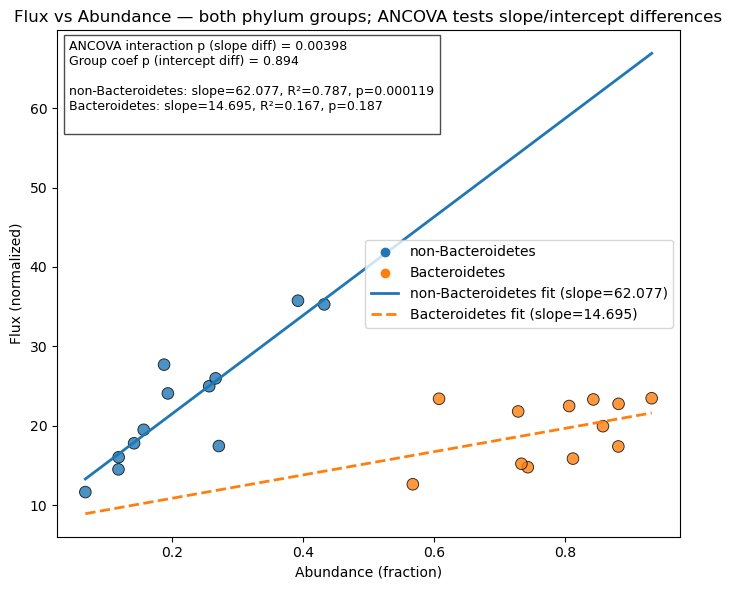

                            OLS Regression Results                            
Dep. Variable:                   flux   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     14.16
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           3.52e-05
Time:                        00:59:50   Log-Likelihood:                -63.911
No. Observations:                  24   AIC:                             135.8
Df Residuals:                      20   BIC:                             140.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [119]:
# ...existing code...
# plot both groups on same axes and test slope/intercept differences (ANCOVA / interaction)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import linregress

# df expected: columns phylum, sample_id, abundance, flux
df = combined_donor.copy()
df['phylum_group'] = df['phylum'].apply(lambda x: 'Bacteroidetes' if x == 'Bacteroidetes' else 'non-Bacteroidetes')
df['phylum_group'] = pd.Categorical(df['phylum_group'], categories=['non-Bacteroidetes', 'Bacteroidetes'])

# fit linear model with interaction: flux ~ abundance * phylum_group
model = smf.ols('flux ~ abundance * C(phylum_group)', data=df).fit()

# extract coefficients (reference = non-Bacteroidetes)
params = model.params
# names used by statsmodels:
coef_abundance = params.get('abundance', 0.0)
coef_group = params.get('C(phylum_group)[T.Bacteroidetes]', 0.0)           # intercept difference
coef_interaction = params.get('abundance:C(phylum_group)[T.Bacteroidetes]', 0.0)  # slope difference
intercept_ref = params.get('Intercept', 0.0)
intercept_bact = intercept_ref + coef_group
slope_ref = coef_abundance
slope_bact = coef_abundance + coef_interaction

# p-values
p_intercept_diff = model.pvalues.get('C(phylum_group)[T.Bacteroidetes]', np.nan)
p_slope_diff = model.pvalues.get('abundance:C(phylum_group)[T.Bacteroidetes]', np.nan)

# also compute separate OLS fits for annotation (R², slope, p)
summary_stats = {}
for grp in df['phylum_group'].cat.categories:
    sub = df[df['phylum_group'] == grp]
    if len(sub) >= 2:
        s = linregress(sub['abundance'].astype(float), sub['flux'].astype(float))
        summary_stats[grp] = {'slope': s.slope, 'intercept': s.intercept, 'r': s.rvalue, 'r2': s.rvalue**2, 'p': s.pvalue}
    else:
        summary_stats[grp] = None

# plotting
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='abundance', y='flux', hue='phylum_group', s=70, edgecolor='k', alpha=0.8)

# lines from model coefficients
xx = np.linspace(df['abundance'].min(), df['abundance'].max(), 200)
yy_ref = intercept_ref + slope_ref * xx
yy_bact = intercept_bact + slope_bact * xx
plt.plot(xx, yy_ref, color='C0', lw=2, label=f'non-Bacteroidetes fit (slope={slope_ref:.3f})')
plt.plot(xx, yy_bact, color='C1', lw=2, label=f'Bacteroidetes fit (slope={slope_bact:.3f})', linestyle='--')

# annotate stats
txt = (
    f"ANCOVA interaction p (slope diff) = {p_slope_diff:.3g}\n"
    f"Group coef p (intercept diff) = {p_intercept_diff:.3g}\n\n"
)
for grp, stats in summary_stats.items():
    if stats:
        txt += (f"{grp}: slope={stats['slope']:.3f}, R²={stats['r2']:.3f}, p={stats['p']:.3g}\n")
    else:
        txt += f"{grp}: insufficient points\n"

plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va='top', fontsize=9,
               bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel('Abundance (fraction)')
plt.ylabel('Flux (normalized)')
plt.title('Flux vs Abundance — both phylum groups; ANCOVA tests slope/intercept differences')
plt.legend(loc='right')
plt.tight_layout()
plt.show()

# print model summary (optional)
print(model.summary())
# ...existing code...

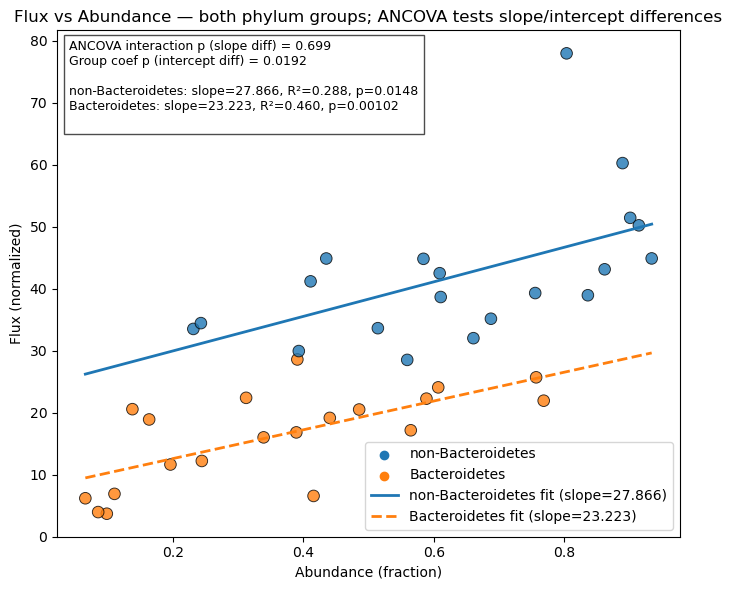

                            OLS Regression Results                            
Dep. Variable:                   flux   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     40.32
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           1.33e-11
Time:                        01:00:06   Log-Likelihood:                -138.47
No. Observations:                  40   AIC:                             284.9
Df Residuals:                      36   BIC:                             291.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [121]:
# ...existing code...
# plot both groups on same axes and test slope/intercept differences (ANCOVA / interaction)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import linregress

# df expected: columns phylum, sample_id, abundance, flux
df = combined_recipients_t0.copy()
df['phylum_group'] = df['phylum'].apply(lambda x: 'Bacteroidetes' if x == 'Bacteroidetes' else 'non-Bacteroidetes')
df['phylum_group'] = pd.Categorical(df['phylum_group'], categories=['non-Bacteroidetes', 'Bacteroidetes'])

# fit linear model with interaction: flux ~ abundance * phylum_group
model = smf.ols('flux ~ abundance * C(phylum_group)', data=df).fit()

# extract coefficients (reference = non-Bacteroidetes)
params = model.params
# names used by statsmodels:
coef_abundance = params.get('abundance', 0.0)
coef_group = params.get('C(phylum_group)[T.Bacteroidetes]', 0.0)           # intercept difference
coef_interaction = params.get('abundance:C(phylum_group)[T.Bacteroidetes]', 0.0)  # slope difference
intercept_ref = params.get('Intercept', 0.0)
intercept_bact = intercept_ref + coef_group
slope_ref = coef_abundance
slope_bact = coef_abundance + coef_interaction

# p-values
p_intercept_diff = model.pvalues.get('C(phylum_group)[T.Bacteroidetes]', np.nan)
p_slope_diff = model.pvalues.get('abundance:C(phylum_group)[T.Bacteroidetes]', np.nan)

# also compute separate OLS fits for annotation (R², slope, p)
summary_stats = {}
for grp in df['phylum_group'].cat.categories:
    sub = df[df['phylum_group'] == grp]
    if len(sub) >= 2:
        s = linregress(sub['abundance'].astype(float), sub['flux'].astype(float))
        summary_stats[grp] = {'slope': s.slope, 'intercept': s.intercept, 'r': s.rvalue, 'r2': s.rvalue**2, 'p': s.pvalue}
    else:
        summary_stats[grp] = None

# plotting
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='abundance', y='flux', hue='phylum_group', s=70, edgecolor='k', alpha=0.8)

# lines from model coefficients
xx = np.linspace(df['abundance'].min(), df['abundance'].max(), 200)
yy_ref = intercept_ref + slope_ref * xx
yy_bact = intercept_bact + slope_bact * xx
plt.plot(xx, yy_ref, color='C0', lw=2, label=f'non-Bacteroidetes fit (slope={slope_ref:.3f})')
plt.plot(xx, yy_bact, color='C1', lw=2, label=f'Bacteroidetes fit (slope={slope_bact:.3f})', linestyle='--')

# annotate stats
txt = (
    f"ANCOVA interaction p (slope diff) = {p_slope_diff:.3g}\n"
    f"Group coef p (intercept diff) = {p_intercept_diff:.3g}\n\n"
)
for grp, stats in summary_stats.items():
    if stats:
        txt += (f"{grp}: slope={stats['slope']:.3f}, R²={stats['r2']:.3f}, p={stats['p']:.3g}\n")
    else:
        txt += f"{grp}: insufficient points\n"

plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va='top', fontsize=9,
               bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel('Abundance (fraction)')
plt.ylabel('Flux (normalized)')
plt.title('Flux vs Abundance — both phylum groups; ANCOVA tests slope/intercept differences')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# print model summary (optional)
print(model.summary())
# ...existing code...

In [129]:
DonorRecipientMapping = pd.read_csv('./goll_et.al_2020_IBS_FMT/raw/DonorRecipientMapping.csv')
# DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient t6'] = DonorRecipientMapping['recipient'].str.split('_').str[0].str.replace('-0', '-6')
DonorRecipientMapping

,recipient_alias,donor_alias,donor,clinical_response,recipient,recipient t6
0,SAMEA7082340,SAMEA7082425,D-2_S7,responder,11-0_S2,11-6
1,SAMEA7082343,SAMEA7082425,D-2_S7,non-responder,12-0_S7,12-6
2,SAMEA7082347,SAMEA7082426,D-3_S6,responder,16-0_S1,16-6
3,SAMEA7082352,SAMEA7082431,D-7Fryst_S7,non-responder,18-0_S6,18-6
4,SAMEA7082355,SAMEA7082426,D-3_S6,responder,19-0_S4,19-6
5,SAMEA7082359,SAMEA7082426,D-3_S6,non-responder,22-0_S2,22-6
6,SAMEA7082361,SAMEA7082427,D-4_S10,non-responder,23-0_S5,23-6
7,SAMEA7082362,SAMEA7082429,D-6Fresk_S5,responder,24-0_S6,24-6
8,SAMEA7082365,SAMEA7082429,D-6Fresk_S5,responder,25-0_S7,25-6
9,SAMEA7082368,SAMEA7082417,D-1_S9,responder,3-0_S1,3-6


In [131]:
combined_recipients_t6 = (
    res.exchanges
    .query('sample_id.isin(@recipients_t6)')
    .drop(columns=res.exchanges.columns.difference(['abundance', 'taxon', 'flux', 'metabolite', 'sample_id', 'direction']))
    .query('metabolite.isin(@scfas) & taxon != "medium"')
    .assign(taxon=lambda x: x['taxon'].astype(str),
            flux=lambda x: np.where(
                x['direction'] == 'export',
                x['flux'] * x['abundance'],
                0
            ))
    .groupby(['taxon', 'sample_id'], as_index=False).agg(
        {
            'abundance': 'first',
            'flux': 'sum'
        }
    )
    .merge(
        ref_taxonomy[['phylum', 'order', 'taxon_id']] # try phylum level, if rank too high, lower to order
        .assign(taxon_id=lambda x: x['taxon_id'].astype(str)),
        left_on='taxon',
        right_on='taxon_id',
        how='left')
    .assign(phylum=lambda x: np.where(
        x['phylum'] == 'Bacteroidetes',
        'Bacteroidetes',
        'non-Bacteroidetes'
    ))
    .drop(columns=['taxon_id'])
    .groupby(['phylum', 'sample_id'], as_index=False).agg(
        {
            'flux': 'sum',
            'abundance': 'sum'
        }
    ) 
    .merge(
        DonorRecipientMapping[['recipient t6', 'clinical_response']],
        left_on='sample_id',
        right_on='recipient t6',
        how='left'
    )
    .drop(columns=['recipient t6'])
)
combined_recipients_t6

,phylum,sample_id,flux,abundance,clinical_response
0,Bacteroidetes,11-6,17.901834,0.719362,responder
1,Bacteroidetes,12-6,6.915596,0.081663,non-responder
2,Bacteroidetes,16-6,12.957981,0.776195,responder
3,Bacteroidetes,18-6,4.356229,0.039080,non-responder
4,Bacteroidetes,19-6,17.859679,0.805737,responder
5,Bacteroidetes,22-6,10.504580,0.245642,non-responder
6,Bacteroidetes,24-6,14.206864,0.730224,responder
7,Bacteroidetes,25-6,21.522293,0.407309,responder
8,Bacteroidetes,3-6,9.000685,0.387138,responder
9,Bacteroidetes,30-6,23.452578,0.706075,responder


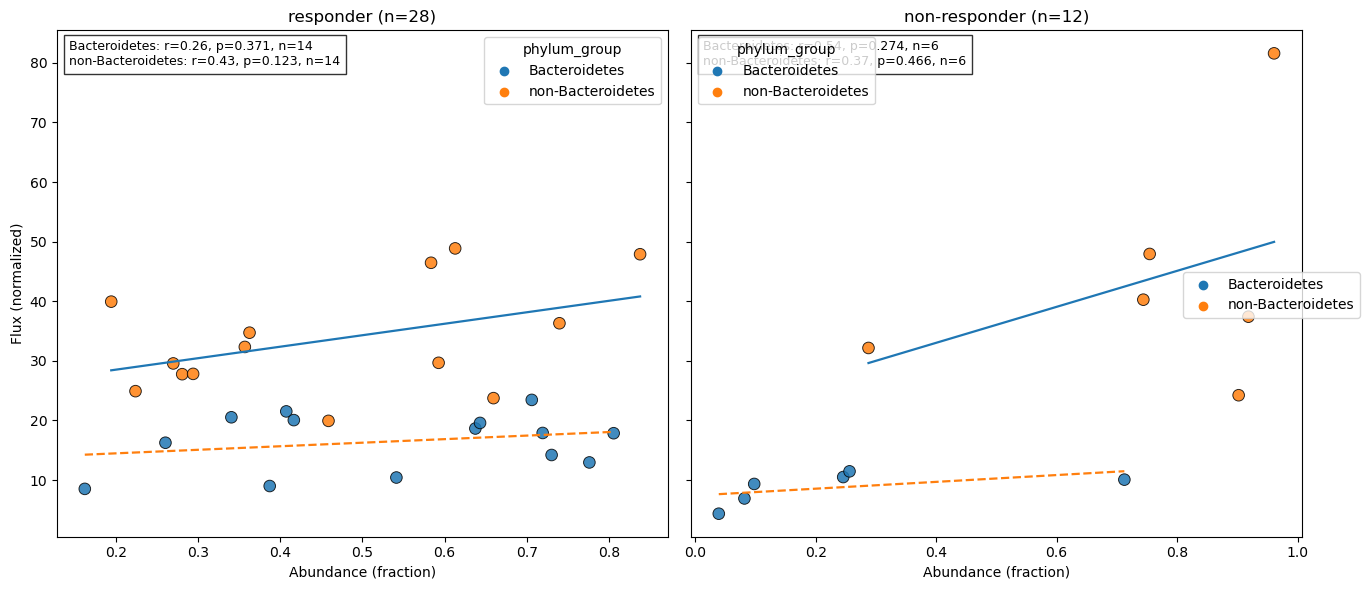

  clinical_response             phylum   n  pearson_r         p      slope  \
0     non-responder      Bacteroidetes   6   0.535386  0.273652   5.714961   
1     non-responder  non-Bacteroidetes   6   0.373702  0.465541  30.189766   
2         responder      Bacteroidetes  14   0.259146  0.370971   5.951445   
3         responder  non-Bacteroidetes  14   0.432024  0.122917  19.255010   

   intercept        r2  
0   7.412196  0.286639  
1  20.954276  0.139653  
2  13.294251  0.067157  
3  24.674099  0.186644  


In [136]:
# ...existing code...
# Plot responders and non-responders separately (each panel shows both phylum groups).
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, linregress
import pandas as pd

df = combined_recipients_t6.copy()  # expects clinical_response merged
df['phylum_group'] = df['phylum'].apply(lambda x: 'Bacteroidetes' if x == 'Bacteroidetes' else 'non-Bacteroidetes')
df['clinical_response'] = df['clinical_response'].fillna('unknown').astype(str)

panels = ['responder', 'non-responder']
phyl_categories = ['Bacteroidetes', 'non-Bacteroidetes']
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plt.subplots_adjust(right=0.8, wspace=0.25)

summary_rows = []
for ax, cr in zip(axes, panels):
    sub = df[df['clinical_response'] == cr].copy()
    ax.set_title(f"{cr} (n={len(sub)})")
    if len(sub) == 0:
        ax.text(0.5, 0.5, "no points", ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('Abundance (fraction)')
        ax.set_ylabel('Flux (normalized)')
        continue

    # scatter both groups
    sns.scatterplot(data=sub, x='abundance', y='flux', hue='phylum_group', s=70, edgecolor='k', alpha=0.85, ax=ax)

    annot_lines = []
    # per-phylum stats + regression lines
    for ph in phyl_categories:
        grp = sub[sub['phylum_group'] == ph]
        n = len(grp)
        if n >= 2 and grp['abundance'].nunique() > 1 and grp['flux'].nunique() > 1:
            x = grp['abundance'].astype(float)
            y = grp['flux'].astype(float)
            r, p = pearsonr(x, y)
            lr = linregress(x, y)
            xx = np.linspace(x.min(), x.max(), 100)
            ax.plot(xx, lr.intercept + lr.slope * xx, lw=1.6, linestyle='--' if ph == 'Bacteroidetes' else '-', 
                    color='C1' if ph == 'Bacteroidetes' else 'C0')
            annot_lines.append(f"{ph}: r={r:.2f}, p={p:.3g}, n={n}")
            summary_rows.append({'clinical_response': cr, 'phylum': ph, 'n': n, 'pearson_r': r, 'p': p,
                                 'slope': lr.slope, 'intercept': lr.intercept, 'r2': lr.rvalue**2})
        else:
            annot_lines.append(f"{ph}: insufficient variation (n={n})")
            summary_rows.append({'clinical_response': cr, 'phylum': ph, 'n': n, 'pearson_r': np.nan, 'p': np.nan,
                                 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan})

    # annotate stats inside panel
    ax.text(0.02, 0.98, "\n".join(annot_lines), transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8))
    ax.set_xlabel('Abundance (fraction)')
    ax.set_ylabel('Flux (normalized)')

# place single legend to the right of the figure to avoid overlap
handles, labels = axes[0].get_legend_handles_labels()
# remove the automatic "phylum_group" title entry if present
if 'phylum_group' in labels:
    # sometimes seaborn puts the legend title in labels; keep only unique labels mapping to handles
    pass
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.98, 0.5))
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# numeric summary
summary_df = pd.DataFrame(summary_rows).sort_values(['clinical_response', 'phylum'])
print(summary_df.reset_index(drop=True))
# ...existing code...

In [142]:
from micom import load_pickle

pk = load_pickle('./goll_et.al_2020_IBS_FMT/models/3-0.pickle')


KeyboardInterrupt: 